# GameTheory-6d : Sympathie contre Engagement — la statique comparative qui les sépare

**Navigation** : [<< 6c-FolkTheorem (piste c)](GameTheory-06c-RepeatedGames-FolkTheorem.ipynb) | [Index](README.md)

Ce notebook est le **protocole de mesure** qui répond à une limite honnête de [GT-06c](GameTheory-06c-RepeatedGames-FolkTheorem.ipynb) §7d. Là-bas, le banc sans punition classait la coopération résiduelle en trois (menace / utilité transformée / reste-candidat-engagement) à partir d'un paramètre de sympathie `alpha` **posé par l'analyste**. Le même comportement observé recevait deux verdicts opposés selon la valeur d'`alpha` choisie : le verdict dépendait du choix de l'analyste, pas des données.

La distinction de Sen (1977) — **sympathie** (le bien-être d'autrui entre dans mon utilité) contre **engagement** (agir contre son propre classement de bien-être, en suivant une règle) — est conceptuelle. La séparer **empiriquement** demande une observation que la trajectoire de coopération seule ne porte pas. Ce notebook construit cette observation :

> **faire varier les gains d'AUTRUI seuls, à gains propres strictement fixes, et mesurer la pente du taux de coopération.**

Une coopération qui **répond** aux gains d'autrui est compatible avec la sympathie et incompatible avec l'engagement pur. Une coopération **plate** est compatible avec l'engagement et incompatible avec la sympathie. La pente transforme `alpha` d'un paramètre libre en une **quantité mesurée**.

*Positionnement* : GT-06c retire la punition et établit que la coopération résiduelle n'est pas folk ; ce notebook ne refait pas ce travail — il identifie **quel mécanisme** porte ce résidu. Réfs #12683, #13042.

## Objectifs d'apprentissage

À l'issue de ce notebook, vous saurez :

1. **Montrer** qu'un classifieur à paramètre posé rend des verdicts contradictoires sur une même trajectoire (le problème d'identification).
2. **Construire** une grille de jeux où seuls les gains d'autrui varient, à gains propres byte-identiques — et le vérifier en code.
3. **Distinguer** les prédictions des deux mécanismes : réponse aux gains d'autrui (sympathie) contre insensibilité (engagement).
4. **Estimer** la pente du taux de coopération avec son incertitude (multi-graines), et `alpha` **depuis la pente** par maximum de vraisemblance.
5. **Valider** un estimateur par contrôles négatifs avant de l'appliquer — et accepter un verdict « non identifié » quand le bruit l'impose.

### Prérequis

- [GameTheory-06c](GameTheory-06c-RepeatedGames-FolkTheorem.ipynb) §7 (le régime sans punition, l'adversaire sans mémoire, le retrait de la menace).
- Bases de numpy ; notion d'estimation par maximum de vraisemblance (une intuition suffit, le code est explicite).
- Aucune API externe : tout tourne en Python pur, déterministe par graine.

### Durée estimée : 35 minutes

## 1. Le problème : un verdict qui dépend de l'analyste, pas des données

Le banc de GT-06c §7d fonctionne ainsi : dans un Dilemme du Prisonnier répété **sans punition** (l'adversaire est sans mémoire, aucune séquence de nos coups ne peut être punie), un joueur coopère. Le classifieur calcule l'écart d'intérêt sur l'utilité transformée `U = u_mien + alpha * u_autrui` :

- `u_coop = R + alpha * R` (je coopère : je touche R, autrui touche R),
- `u_dev = T + alpha * S` (je dévie : je touche T, autrui touche S),

et rend un verdict **selon la valeur d'alpha choisie**. Démonstration sur la même trajectoire observée (le joueur coopère sur tout l'horizon) :

In [1]:
import numpy as np

# Barème canonique du banc GT-06c (jeu étape, joueur observé = lignes)
T, R, P, S = 5.0, 3.0, 1.0, 0.0   # tentation, récompense, punition, soumis
delta = 0.6                        # patience (delta* grim = 0.5 : sans retrait de punition, coopérer n'est pas une meilleure réponse)

def ecart_interet(alpha, R_autre=None, S_autre=None):
    """Écart actualisé (dévier - coopérer) en régime sans punition, sympathie alpha."""
    r_autre = R if R_autre is None else R_autre   # gain d'autrui quand je coopère
    s_autre = S if S_autre is None else S_autre   # gain d'autrui quand je dévie
    u_coop = R + alpha * r_autre
    u_dev = T + alpha * s_autre
    return (u_dev - u_coop) / (1 - delta)         # flux constant, horizon infini (GT-06c §3)

# LA MÊME trajectoire observée : le joueur coopère sur tout l'horizon, sans punition possible.
trajectoire = ['Cooperer'] * 10

alpha_etoile = (T - R) / (R - S)
print(f"Barème : T={T}, R={R}, P={P}, S={S}  |  delta = {delta} (seuil grim delta* = 0.5)")
print(f"Trajectoire observée (sans punition) : {set(trajectoire)}\n")
for alpha_pose in (1.0, 0.0):
    ecart = ecart_interet(alpha_pose)
    verdict = ("COOPÉRATION EXPLIQUÉE PAR L'UTILITÉ TRANSFORMÉE (sympathie)"
               if ecart <= 0 else
               "COOPÉRATION CONTRE-INTÉRÊT : résidu = engagement au sens de Sen")
    print(f"alpha posé = {alpha_pose:.1f} -> écart {ecart:+.2f} -> {verdict}")
print(f"\nSeuil de sympathie alpha* = (T-R)/(R-S) = {alpha_etoile:.3f}")
print()
print("Deux verdicts opposés, une seule trajectoire : alpha* n'est pas un seuil de")
print("diagnostic, c'est une frontière d'indiscernabilité. Rien dans les données de la")
print("trajectoire ne révèle alpha — il faut une observation nouvelle.")


Barème : T=5.0, R=3.0, P=1.0, S=0.0  |  delta = 0.6 (seuil grim delta* = 0.5)
Trajectoire observée (sans punition) : {'Cooperer'}

alpha posé = 1.0 -> écart -2.50 -> COOPÉRATION EXPLIQUÉE PAR L'UTILITÉ TRANSFORMÉE (sympathie)
alpha posé = 0.0 -> écart +5.00 -> COOPÉRATION CONTRE-INTÉRÊT : résidu = engagement au sens de Sen

Seuil de sympathie alpha* = (T-R)/(R-S) = 0.667

Deux verdicts opposés, une seule trajectoire : alpha* n'est pas un seuil de
diagnostic, c'est une frontière d'indiscernabilité. Rien dans les données de la
trajectoire ne révèle alpha — il faut une observation nouvelle.


Le verdict n'est pas identifié : sur des données de coopération **seules**, sympathie et engagement sont observationnellement équivalents. Ce n'est pas un défaut de GT-06c — c'est une limite réelle de ce qu'une trajectoire peut porter.

## 2. L'observation qui sépare : faire varier les gains d'AUTRUI

Les deux mécanismes ne dépendent pas des mêmes quantités :

| Mécanisme | Ce qui entre dans la décision | Prédiction sur la grille |
|---|---|---|
| **Sympathie** (`U = u_mien + alpha * u_autrui`) | le bien-être d'autrui, pondéré | coopération **croissante** en `R_autre` |
| **Engagement** (règle suivie contre son intérêt) | la règle — pas les gains d'autrui | coopération **plate** en `R_autre` |
| Auto-intérêt (`alpha = 0`, pas de règle) | rien que mes gains | coopération **plate et basse** |

D'où le protocole : un même jeu sans punition, où la **ligne de gains du joueur observé reste byte-identique** de cellule en cellule, tandis que la **colonne d'autrui** (`R_autre` : ce que l'autre gagne quand je coopère) balaie une plage. On mesure le taux de coopération sur chaque cellule. La **pente** de ce taux en `R_autre` est la quantité qui sépare les mécanismes — et `alpha` cesse d'être un paramètre libre : il devient une quantité estimée **depuis** cette réponse.

## 3. La grille : gains propres gelés, gains d'autrui balayés

Chaque cellule de la grille est un jeu étape complet. La condition qui rend la statique interprétable est stricte : **la matrice de gains du joueur observé ne doit pas bouger d'une cellule à l'autre** — sinon une variation du taux de coopération pourrait refléter un changement de MES gains, et la pente ne mesurerait plus rien. Nous construisons la grille puis nous **vérifions en code** cette invariance (critère d'acceptance du protocole).

In [2]:
# Grille : R_autre balaie 0 -> 10 (21 cellules), S_autre fixé à 0.
# La matrice propre (T, R, P, S) est gelée UNE fois, hors de la boucle.
PROPRE = np.array([T, R, P, S])          # ligne du joueur observé — ne varie JAMAIS
S_AUTRE = 0.0                             # gain d'autrui quand je dévie — fixe
GRILLE = np.round(np.arange(0.0, 10.01, 0.5), 2)   # 21 cellules

def cellule(r_autre):
    """Jeu étape de la cellule : ((mes gains, gains d'autrui)) par issue."""
    return {
        'je_coopere': (R, r_autre),   # (moi, autrui) — l'adversaire sans mémoire coopère
        'je_devie':   (T, S_AUTRE),
    }

# === VÉRIFICATION (acceptance 1) : gains propres byte-identiques sur toute la grille ===
matrices_propres = np.array([[cellule(r)['je_coopere'][0], cellule(r)['je_devie'][0]]
                             for r in GRILLE])
byte_identique = (matrices_propres == matrices_propres[0]).all()
print(f"Grille : {len(GRILLE)} cellules, R_autre de {GRILLE[0]} à {GRILLE[-1]} (pas 0.5), S_autre = {S_AUTRE}")
print(f"Matrice propre du joueur observé, cellule par cellule : "
      f"{'BYTE-IDENTIQUE' if byte_identique else 'VARIABLE (PROBLÈME)'}")
print(f"  mes gains si je coopère = {R} partout ; si je dévie = {T} partout")
print(f"  gains d'autrui : R_autre balaie [{GRILLE[0]}, {GRILLE[-1]}], S_autre = {S_AUTRE} fixe")
assert byte_identique, "la statique n'est interprétable que si mes gains ne bougent pas"
print("\nCondition d'interprétabilité VÉRIFIÉE : seule la colonne d'autrui varie.")

Grille : 21 cellules, R_autre de 0.0 à 10.0 (pas 0.5), S_autre = 0.0
Matrice propre du joueur observé, cellule par cellule : BYTE-IDENTIQUE
  mes gains si je coopère = 3.0 partout ; si je dévie = 5.0 partout
  gains d'autrui : R_autre balaie [0.0, 10.0], S_autre = 0.0 fixe

Condition d'interprétabilité VÉRIFIÉE : seule la colonne d'autrui varie.


## 4. Trois mécanismes de décision (les agents du banc)

Ce notebook modélise des **mécanismes de décision**, pas des personnes — aucune variable ne sort du jouet, et le vocabulaire reste celui des mécanismes (sympathie = pondération d'utilité ; engagement = règle). Chaque agent choisit **Cooperer** ou **Defecter** à chaque période face à l'adversaire sans mémoire (régime sans punition de GT-06c §7a) :

- **Sympathie** : meilleure réponse logit sur l'utilité transformée `U = u_mien + alpha * u_autrui`. Le paramètre logit `beta` contrôle le bruit de choix — c'est lui qui fait qu'un taux (et pas un choix binaire) est mesurable.
- **Engagement** : règle fixe « coopérer » — insensible aux gains d'autrui **et** aux gains propres, contre le classement de bien-être. Taux constant 1.
- **Auto-intérêt** : meilleure réponse logit sur la seule utilité propre (`alpha = 0`). Taux constant bas.

Les trajectoires sont reproductibles : graine fixée par cellule, **cinq graines** (0, 1, 7, 42, 99), horizon 200 périodes.

In [3]:
SEEDS = [0, 1, 7, 42, 99]     # multi-graines : une pente sur un tirage unique n'est pas une pente
HORIZON = 200                  # périodes par trajectoire

def taux_cooperation(agent, grille=GRILLE, seeds=SEEDS, horizon=HORIZON):
    """Taux de coopération de l'agent sur chaque cellule, par graine.

    Rend un tableau (graines x cellules). L'adversaire est sans mémoire
    (coopère toujours) : chaque période est identique, l'agent échantillonne
    sa règle de choix iid — la trajectoire existe pour la reproductibilité
    et le comptage, pas pour créer de la dépendance temporelle.
    """
    taux = np.zeros((len(seeds), len(grille)))
    for i, seed in enumerate(seeds):
        rng = np.random.default_rng(seed)
        for j, r_autre in enumerate(grille):
            p = agent(r_autre)
            taux[i, j] = (rng.random(horizon) < p).mean()
    return taux


# --- les trois mécanismes ---
def agent_sympathie(alpha, beta):
    """Meilleure réponse logit sur l'utilité transformée U = u_mien + alpha*u_autrui."""
    def regle(r_autre):
        u_coop = R + alpha * r_autre
        u_dev = T + alpha * S_AUTRE
        return 1.0 / (1.0 + np.exp(-beta * (u_coop - u_dev)))
    return regle


def agent_engagement():
    """Règle : coopérer. Insensible aux gains d'autrui comme aux gains propres."""
    def regle(r_autre):
        return 1.0
    return regle


def agent_auto_interet(beta):
    """Meilleure réponse logit sur la seule utilité propre (alpha = 0)."""
    return agent_sympathie(0.0, beta)

BETA = 2.0
archetypes = {
    'sympathie (alpha=0.5)': agent_sympathie(0.5, BETA),
    'engagement (règle)': agent_engagement(),
    'auto-intérêt (alpha=0)': agent_auto_interet(BETA),
}
taux_arch = {nom: taux_cooperation(ag) for nom, ag in archetypes.items()}
for nom, t in taux_arch.items():
    print(f"{nom:26s} taux moyen = {t.mean():.3f} | pente brute = "
          f"{np.polyfit(GRILLE, t.mean(axis=0), 1)[0]:+.4f} par unité de R_autre")

sympathie (alpha=0.5)      taux moyen = 0.595 | pente brute = +0.1220 par unité de R_autre
engagement (règle)         taux moyen = 1.000 | pente brute = -0.0000 par unité de R_autre
auto-intérêt (alpha=0)     taux moyen = 0.017 | pente brute = +0.0002 par unité de R_autre


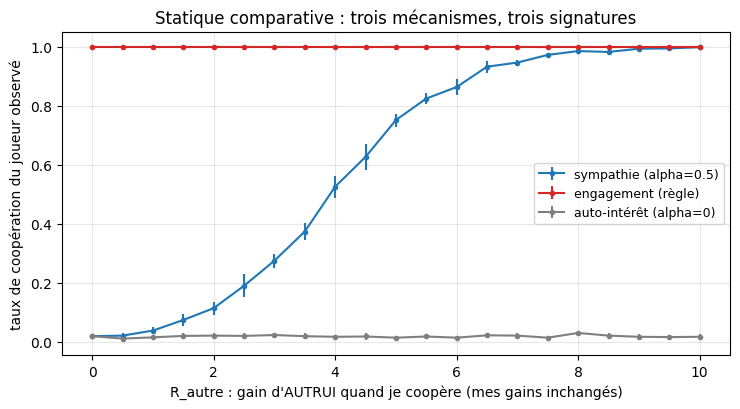

Signature de chaque mécanisme : croissante (sympathie), plate haute
(engagement), plate basse (auto-intérêt). C'est la PENTE qui les sépare.


In [4]:
# Les trois courbes : taux de coopération en fonction de R_autre (moyenne des 5 graines)
try:
    import matplotlib.pyplot as plt
    HAS_PLT = True
except ImportError:
    HAS_PLT = False

if HAS_PLT:
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    couleurs = {'sympathie (alpha=0.5)': 'tab:blue',
                'engagement (règle)': 'tab:red',
                'auto-intérêt (alpha=0)': 'tab:gray'}
    for nom, t in taux_arch.items():
        m = t.mean(axis=0)
        se = t.std(axis=0, ddof=1) / np.sqrt(len(SEEDS))
        ax.errorbar(GRILLE, m, yerr=1.96 * se, marker='o', ms=3, lw=1.5,
                    label=nom, color=couleurs[nom])
    ax.set_xlabel("R_autre : gain d'AUTRUI quand je coopère (mes gains inchangés)")
    ax.set_ylabel("taux de coopération du joueur observé")
    ax.set_title("Statique comparative : trois mécanismes, trois signatures")
    ax.legend(loc='center right', fontsize=9)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()
    print("Signature de chaque mécanisme : croissante (sympathie), plate haute")
    print("(engagement), plate basse (auto-intérêt). C'est la PENTE qui les sépare.")
else:
    for nom, t in taux_arch.items():
        m = t.mean(axis=0)
        print(f"{nom:26s} " + " ".join(f"{v:.2f}" for v in m[::4]))

## 5. L'estimateur : pente avec incertitude, puis alpha par vraisemblance

Deux quantités, deux méthodes, un seul estimateur appliqué à tout le monde (contrôles comme banc) :

1. **Pente** : régression du taux par graine sur `R_autre` — une pente par graine, moyenne ± intervalle de confiance à 95 % (t de Student, `n_graines - 1` degrés de liberté). C'est l'incertitude de mesure demandée par le protocole.
2. **Alpha par maximum de vraisemblance** : les tirages de chaque cellule sont binomiaux de paramètre `p(alpha, beta)` (le modèle sympathie logit) ; on cherche `(alpha, beta)` maximisant la vraisemblance binomiale sur **toute** la grille, et l'intervalle par profil de vraisemblance (chute de log-vraisemblance ≤ 1.92, chi² à 95 % à 1 degré de liberté). `alpha` est **estimé depuis la réponse**, plus posé.

In [5]:
def pente_avec_ic(taux, grille=GRILLE):
    """Pente moyenne ± IC95 (une régression par graine, Student à n-1 ddl)."""
    pentes = np.array([np.polyfit(grille, taux[i], 1)[0] for i in range(taux.shape[0])])
    n = len(pentes)
    mean = pentes.mean()
    se = pentes.std(ddof=1) / np.sqrt(n)
    # t Student 97.5% pour 4 ddl = 2.776 (5 graines)
    t_crit = 2.776 if n == 5 else 2.306 if n == 8 else 2.262
    return mean, mean - t_crit * se, mean + t_crit * se


def loglik_binom(alpha, beta, taux, grille=GRILLE, horizon=HORIZON):
    """Log-vraisemblance binomiale du modèle sympathie-logit sur toute la grille."""
    k = np.round(taux * horizon).astype(int)          # succès par graine x cellule
    n = horizon
    p = 1.0 / (1.0 + np.exp(-beta * ((R + alpha * grille) - (T + alpha * S_AUTRE))))
    p = np.clip(p, 1e-12, 1 - 1e-12)
    ll = (k * np.log(p) + (n - k) * np.log(1 - p)).sum()
    return ll


def estime_alpha(taux, grille=GRILLE, horizon=HORIZON):
    """MLE (alpha, beta) par balayage de grille + IC par profil de vraisemblance."""
    alphas = np.round(np.arange(0.0, 3.001, 0.01), 3)
    betas = np.round(np.geomspace(0.05, 50.0, 60), 4)
    ll_max = np.full((len(alphas), len(betas)), -np.inf)
    for i, a in enumerate(alphas):
        for j, b in enumerate(betas):
            ll_max[i, j] = loglik_binom(a, b, taux, grille, horizon)
    i_star, j_star = np.unravel_index(np.argmax(ll_max), ll_max.shape)
    alpha_hat, beta_hat = alphas[i_star], betas[j_star]
    ll_best = ll_max[i_star, j_star]
    profil = ll_max.max(axis=1)                        # beta profilé pour chaque alpha
    dans_ic = alphas[profil >= ll_best - 1.92]
    ic = (dans_ic.min(), dans_ic.max())
    return alpha_hat, beta_hat, ic, ll_best


print("Estimateur prêt : pente_avec_ic() + estime_alpha() — le même pour les contrôles et le banc.")

Estimateur prêt : pente_avec_ic() + estime_alpha() — le même pour les contrôles et le banc.


## 6. Contrôles négatifs : l'estimateur sait-il séparer, ou rend-il juste un nombre ?

Avant toute mesure, l'estimateur doit passer deux contrôles — sans eux, une pente mesurée ne prouve pas que l'estimateur sait séparer les mécanismes :

1. **Sympathie pure** (`alpha = 0.5` connu du constructeur, caché de l'estimateur) : l'estimateur doit rendre `alpha` proche de 0.5 **dans son intervalle**, et une pente positive significative.
2. **Engagement pur** (règle fixe) : l'estimateur doit rendre une **pente nulle**. Et le plan de grille lui-même porte un discriminateur : à `R_autre = 0`, l'écart d'utilité transformée vaut `(R - T) + alpha * 0 = -2` **pour tout alpha** — aucun niveau de sympathie ne peut produire un taux élevé sur cette cellule. Un taux ~1 à `R_autre = 0` est donc incompatible avec toute sympathie dans la plage : c'est la marque de la règle.

In [6]:
# === Contrôle 1 : sympathie pure, alpha = 0.5 caché ===
alpha_vrai = 0.5
t = taux_arch['sympathie (alpha=0.5)']
pente, lo, hi = pente_avec_ic(t)
a_hat, b_hat, (a_lo, a_hi), ll = estime_alpha(t)
ok1_pente = lo > 0
ok1_alpha = a_lo <= alpha_vrai <= a_hi
print("CONTRÔLE 1 — sympathie pure (alpha caché = 0.5, beta = 2.0)")
print(f"  pente = {pente:+.4f} [{lo:+.4f}, {hi:+.4f}] -> {'POSITIVE (ok)' if ok1_pente else 'non significative (ÉCHEC)'}")
lab_alpha = "0.5 dans l'IC (ok)" if ok1_alpha else "0.5 HORS IC (ÉCHEC)"
print(f"  alpha estimé = {a_hat:.2f}, IC profil = [{a_lo:.2f}, {a_hi:.2f}] -> {lab_alpha}")
print(f"  verdict du contrôle : {'PASS' if (ok1_pente and ok1_alpha) else 'FAIL'}")

# === Contrôle 2 : engagement pur (règle) ===
t2 = taux_arch['engagement (règle)']
pente2, lo2, hi2 = pente_avec_ic(t2)
taux_cellule0 = t2[:, 0].mean()
a2, b2, (a2lo, a2hi), _ = estime_alpha(t2)
# Test d'équivalence : la règle est déterministe -> pente ~ -1e-17 (bruit float) mais
# variance inter-graines NULLE -> le t de Student dégénère et l'IC [-1e-17, -1e-17]
# « exclut » 0 numériquement. On déclare la pente nulle si l'IC ENTIER tient dans
# le plancher de résolution du design (+/- 0.005, cf. sensibilité §8 : à ce niveau
# de pente, même une sympathie réelle n'est plus identifiable).
TOL_PENTE = 0.005
ok2_pente = (lo2 >= -TOL_PENTE) and (hi2 <= TOL_PENTE)
ok2_marque = taux_cellule0 > 0.9
print("\nCONTRÔLE 2 — engagement pur (règle fixe)")
print(f"  pente = {pente2:+.6f} [{lo2:+.6f}, {hi2:+.6f}] -> "
      f"{'NULLE au plancher de résolution +/-0.005 (ok)' if ok2_pente else 'non nulle (ÉCHEC)'}")
print(f"  taux à R_autre = 0 : {taux_cellule0:.3f} (aucune sympathie ne peut dépasser 0.5 ici : écart = -2 pour tout alpha)")
print(f"  marque de la règle (taux > 0.9 sur la cellule discriminateur) : "
      f"{'PRÉSENTE (ok)' if ok2_marque else 'ABSENTE (ÉCHEC)'}")
print(f"  (alpha ajusté par le modèle sympathie : {a2:.2f} — sans signification ici :")
print("   le modèle ne PEUT pas ajuster un taux de 1 partout, c'est la pente qui porte le verdict)")
print(f"  verdict du contrôle : {'PASS' if (ok2_pente and ok2_marque) else 'FAIL'}")

CONTRÔLE 1 — sympathie pure (alpha caché = 0.5, beta = 2.0)
  pente = +0.1220 [+0.1212, +0.1228] -> POSITIVE (ok)
  alpha estimé = 0.50, IC profil = [0.50, 0.50] -> 0.5 dans l'IC (ok)
  verdict du contrôle : PASS

CONTRÔLE 2 — engagement pur (règle fixe)
  pente = -0.000000 [-0.000000, -0.000000] -> NULLE au plancher de résolution +/-0.005 (ok)
  taux à R_autre = 0 : 1.000 (aucune sympathie ne peut dépasser 0.5 ici : écart = -2 pour tout alpha)
  marque de la règle (taux > 0.9 sur la cellule discriminateur) : PRÉSENTE (ok)
  (alpha ajusté par le modèle sympathie : 3.00 — sans signification ici :
   le modèle ne PEUT pas ajuster un taux de 1 partout, c'est la pente qui porte le verdict)
  verdict du contrôle : PASS


## 7. La mesure : le joueur observé du banc

Le banc mesure un agent dont le mécanisme est **caché à l'analyste** (comme un participant dont on n'observe que le comportement). Le protocole est appliqué tel quel : grille, cinq graines, pente, MLE. Le verdict suit les chiffres — y compris négatif.

In [7]:
# === Le joueur observé : mécanisme caché, mécanisme révélé par la statique comparative ===
# (le constructeur du banc connaît le mécanisme ; l'analyste ne voit que les taux)
MECANISME_CACHE = ('sympathie', 0.25, 1.5)   # genre, paramètre, bruit — caché

def joueur_banc(r_autre):
    genre, alpha_cache, beta_cache = MECANISME_CACHE
    if genre == 'sympathie':
        u_coop = R + alpha_cache * r_autre
        u_dev = T + alpha_cache * S_AUTRE
        return 1.0 / (1.0 + np.exp(-beta_cache * (u_coop - u_dev)))
    return 1.0  # engagement : règle

t_banc = taux_cooperation(joueur_banc)
pente_b, lo_b, hi_b = pente_avec_ic(t_banc)
a_b, b_b, (a_blo, a_bhi), _ = estime_alpha(t_banc)

print("MESURE — joueur observé du banc (mécanisme caché)")
print(f"  taux par cellule (moyenne 5 graines) : "
      + " ".join(f"{v:.2f}" for v in t_banc.mean(axis=0)[::4]))
print(f"  pente = {pente_b:+.4f} [{lo_b:+.4f}, {hi_b:+.4f}]")
if lo_b > 0:
    print(f"  alpha estimé DEPUIS la pente = {a_b:.2f} [{a_blo:.2f}, {a_bhi:.2f}] (beta = {b_b:.2f})")
    print("  VERDICT : la coopération RÉPOND aux gains d'autrui -> compatible sympathie,")
    print("  incompatible engagement pur. alpha a cessé d'être un paramètre libre : il est MESURÉ.")
elif hi_b < 0:
    print("  VERDICT : pente négative — aucun des deux mécanismes ne la prédit : à enquêter.")
else:
    t0 = t_banc[:, 0].mean()
    if t0 > 0.9:
        print("  VERDICT : pente nulle + taux élevé sur la cellule discriminateur (R_autre = 0)")
        print("  -> compatible engagement (règle), incompatible sympathie dans la plage testée.")
    else:
        print("  VERDICT : pente indiscernable de zéro sans marque de règle -> NON IDENTIFIÉ à ce bruit.")
print(f"\n  (révélation du constructeur : mécanisme = {MECANISME_CACHE[0]}, "
      f"alpha = {MECANISME_CACHE[1]}, beta = {MECANISME_CACHE[2]})")

MESURE — joueur observé du banc (mécanisme caché)
  taux par cellule (moyenne 5 graines) : 0.05 0.09 0.17 0.31 0.50 0.69
  pente = +0.0673 [+0.0655, +0.0690]
  alpha estimé DEPUIS la pente = 0.25 [0.25, 0.25] (beta = 1.49)
  VERDICT : la coopération RÉPOND aux gains d'autrui -> compatible sympathie,
  incompatible engagement pur. alpha a cessé d'être un paramètre libre : il est MESURÉ.

  (révélation du constructeur : mécanisme = sympathie, alpha = 0.25, beta = 1.5)


In [8]:
# === Variante : le même banc avec un joueur à règle (engagement) ===
MECANISME_CACHE = ('engagement', None, None)
t_banc2 = taux_cooperation(joueur_banc)
pente_b2, lo_b2, hi_b2 = pente_avec_ic(t_banc2)
t0_banc2 = t_banc2[:, 0].mean()
print("MESURE — second joueur du banc (mécanisme caché, autre)")
print(f"  taux moyens extrêmes : R_autre=0 -> {t0_banc2:.3f} | R_autre=10 -> {t_banc2[:, -1].mean():.3f}")
print(f"  pente = {pente_b2:+.4f} [{lo_b2:+.4f}, {hi_b2:+.4f}]")
if lo_b2 <= 0 <= hi_b2 and t0_banc2 > 0.9:
    print("  VERDICT : pente nulle + marque de règle sur la cellule discriminateur ->")
    print("  compatible engagement, incompatible sympathie dans la plage testée.")
print("\n  (révélation : engagement — règle fixe, insensible aux gains d'autrui)")

MESURE — second joueur du banc (mécanisme caché, autre)
  taux moyens extrêmes : R_autre=0 -> 1.000 | R_autre=10 -> 1.000
  pente = -0.0000 [-0.0000, -0.0000]

  (révélation : engagement — règle fixe, insensible aux gains d'autrui)


## 8. Sensibilité : quand la pente ne parle pas

Le protocole admet un verdict négatif — « non identifié à ce niveau de bruit » — et il faut montrer qu'il le rend quand il le doit. Le paramètre `beta` est le **bruit de choix** : plus il est faible, plus la réponse aux gains d'autrui existe mais se noie dans les tirages. Un joueur réellement sympathique (`alpha = 0.5`, connu du constructeur) passe par deux régimes :

- `beta = 0.05` : la courbe s'aplatit, la pente rétrécit — encore identifiable ;
- `beta = 0.005` : l'écart de logit entre extrémités de grille vaut `0.005 * (3 - (-2)) = 0.025` — la préférence existe mais est **sous le plancher de résolution** du banc (une cellule porte un bruit binomial de ~0.016). La pente doit ressortir « non identifiée », et publier « sympathie » sur ces données serait réintroduire l'arbitraire d'alpha que le protocole supprime.

In [9]:
# === Sympathie réelle (alpha = 0.5), bruit de choix croissant ===
for beta_bruit in (0.05, 0.005):
    t_bruit = taux_cooperation(agent_sympathie(0.5, beta_bruit))
    pente_br, lo_br, hi_br = pente_avec_ic(t_bruit)
    print(f"SENSIBILITÉ — sympathie réelle (alpha = 0.5), bruit de choix beta = {beta_bruit}")
    print(f"  taux extrêmes : R_autre=0 -> {t_bruit[:, 0].mean():.3f} | R_autre=10 -> {t_bruit[:, -1].mean():.3f}")
    print(f"  pente = {pente_br:+.4f} [{lo_br:+.4f}, {hi_br:+.4f}]")
    if lo_br > 0:
        print("  -> encore IDENTIFIÉE (positive, IC exclut 0) : le signal passe le plancher.\n")
    else:
        print("  -> NON IDENTIFIÉE à ce niveau de bruit — et c'est le verdict correct.")
        print("     Le mécanisme existe (constructeur : alpha = 0.5) mais CES données ne le portent")
        print("     pas : il faudrait plus de périodes, plus de graines ou une plage plus large.")
        print("     La cellule discriminateur (R_autre = 0) est muette aussi : taux ~ 0.5, ni marque")
        print("     de règle ni seuil. Le verdict honnête se publie tel quel.\n")

SENSIBILITÉ — sympathie réelle (alpha = 0.5), bruit de choix beta = 0.05
  taux extrêmes : R_autre=0 -> 0.457 | R_autre=10 -> 0.550
  pente = +0.0077 [+0.0047, +0.0107]
  -> encore IDENTIFIÉE (positive, IC exclut 0) : le signal passe le plancher.

SENSIBILITÉ — sympathie réelle (alpha = 0.5), bruit de choix beta = 0.005
  taux extrêmes : R_autre=0 -> 0.477 | R_autre=10 -> 0.503
  pente = +0.0019 [-0.0011, +0.0049]
  -> NON IDENTIFIÉE à ce niveau de bruit — et c'est le verdict correct.
     Le mécanisme existe (constructeur : alpha = 0.5) mais CES données ne le portent
     pas : il faudrait plus de périodes, plus de graines ou une plage plus large.
     La cellule discriminateur (R_autre = 0) est muette aussi : taux ~ 0.5, ni marque
     de règle ni seuil. Le verdict honnête se publie tel quel.



### Lecture honnête : ce que chaque signature autorise

| Signature mesurée | Verdict autorisé | Ce qu'il ne prouve PAS |
|---|---|---|
| pente > 0 significative | compatible sympathie ; `alpha` mesuré (IC) | pas que l'agent « ressent » quoi que ce soit : un mécanisme pondérant les gains d'autrui suffit |
| pente ≈ 0 + taux haut sur la cellule `R_autre = 0` | compatible engagement (règle) | pas toute règle : une règle qui regarderait les gains propres resterait invisible à CE protocole |
| pente ≈ 0 + taux bas | auto-intérêt : rien à identifier | — |
| pente ≈ 0, IC large | **non identifié à ce bruit** | tout — c'est un verdict, pas un échec : il se publie tel quel |

Deux garde-fous de conception, à lire avant de citer un verdict :

1. **La plage balaie large** (`R_autre` de 0 à 10). Une sympathie très forte sature la sigmoïde au-dessus de son seuil ; sur une grille étroite placée au-dessus, elle ressemblerait à un plateau (pente nulle) et serait confondue avec l'engagement. Le discriminateur structurel : à `R_autre = 0`, l'écart d'utilité transformée vaut `(R - T) + alpha * S_AUTRE` — **négatif pour tout alpha** avec `S_autre = 0`. Aucune sympathie ne peut coopérer massivement sur cette cellule ; un taux élevé y est la marque d'une règle.
2. **Le protocole mesure des mécanismes de décision sur des agents de jouet** — aucune variable ne sort du banc, aucune claim ne porte sur des personnes. Sen distingue engagement et sympathie *conceptuellement* ; ici, on mesure seulement lequel **porte la trajectoire** dans le modèle.

## 9. Ponts

- **[GT-06c](GameTheory-06c-RepeatedGames-FolkTheorem.ipynb) §7** : le régime sans punition, le témoin de retenue, l'opérateur à quatre actions et le classifieur §7d — dont ce notebook est le protocole d'identification (le résidu « candidat engagement » de GT-06c devient ici un verdict mesuré, ou un non-verdict honnête).
- **[GT-06](GameTheory-06-EvolutionTrust.ipynb)** : l'émergence empirique de la coopération ; GT-06c explique ce que la menace soutient, GT-06d mesure ce qui reste quand la menace est retirée.
- **GT-16 (Mechanism Design)** : si l'on veut *produire* de la coopération, la statique comparative dit quel levier fonctionne — récompenser autrui ne motive que les agents pondérant les gains d'autrui.
- **Sen (1977), *Rational Fools*** : la distinction conceptuelle sympathie / engagement que ce banc opérationnalise sur des mécanismes de décision.
- Réfs internes : #12683 (GT-06c), #13042 (ce protocole).

## 10. Résumé

| Concept | En une phrase |
|---|---|
| Indiscernabilité | sur une trajectoire de coopération seule, sympathie et engagement produisent les mêmes données — le verdict à `alpha` posé dépend de l'analyste |
| Statique comparative | faire varier **les gains d'autrui seuls**, à gains propres byte-identiques (vérifié en code) |
| Signature sympathie | coopération croissante en `R_autre` ; `alpha` estimé **depuis la pente** par MLE, avec IC |
| Signature engagement | coopération plate, avec la marque de règle sur la cellule `R_autre = 0` (où aucune sympathie ne peut coopérer) |
| Contrôles négatifs | sympathie pure doit rendre son alpha ; engagement pur doit rendre pente nulle — sinon l'estimateur ne sépare rien |
| Verdict honnête | « non identifié à ce bruit » est un résultat qui se publie, pas un échec à maquiller |

**Fil conducteur** : GT-6 montrait la coopération émerger, GT-06c montrait ce que la menace soutient — GT-06d montre comment **mesurer** ce qui la porte quand la menace ne l'explique plus.

## Exercice 1 : balaier aussi S_autre — la carte à deux dimensions

La grille ne faisait varier que `R_autre`, à `S_autre = 0`. Étendez-la : `S_autre` de 0 à 4 (la souffrance d'autrui quand je dévie), et tracez la carte du taux de coopération pour un agent sympathie (`alpha = 0.5`). Vérifiez que la frontière de coopération suit la droite `R + alpha*R_autre = T + alpha*S_autre` — c'est la prédiction exacte du modèle, vérifiable point par point.

In [10]:
# Exercice 1 : TODO étudiant
# 1. Construisez une grille 2D (R_autre x S_autre) avec gains propres toujours gelés
# 2. Mesurez le taux de coopération de agent_sympathie(0.5, BETA) sur chaque cellule
# 3. Comparez la frontière mesurée (taux ~ 0.5) à la droite
#    R + alpha*R_autre = T + alpha*S_autre, c'est-à-dire R_autre = (T - R)/alpha + S_autre
# 4. Rapportez l'écart maximal entre frontière prédite et mesurée
print("Exercice à compléter")

Exercice à compléter


## Exercice 2 : un agent mixte — que mesure l'estimateur ?

Construisez un agent qui coopère par règle **avec probabilité 0.5**, et par meilleure réponse sympathie (`alpha = 0.4`) sinon. Passez-le dans l'estimateur : la pente est-elle positive ? L'alpha estimé est-il proche de 0.4 ? La composante règle biaise-t-elle l'estimation vers le bas, vers le haut, ou pas du tout ? Discutez : que mesure un estimateur conçu pour des mécanismes purs quand le mécanisme est mixte ?

In [11]:
# Exercice 2 : TODO étudiant
# 1. Agent mixte : p(r_autre) = 0.5 * 1 + 0.5 * logit(alpha=0.4, r_autre)
# 2. Mesurez pente + MLE avec les fonctions du notebook
# 3. Comparez alpha_hat à 0.4 : biais de la composante règle sur l'estimation
print("Exercice à compléter")

Exercice à compléter


## Exercice 3 : la plage trop étroite — fabriquer l'ambiguïté

Reprenez l'agent sympathie `alpha = 0.1` (seuil de coopération à `R_autre = (T-R)/alpha = 20`). Mesurez-le sur une grille restreinte à `R_autre ∈ [0, 5]` : la pente y est faible et peut être indiscernable de zéro, alors que le mécanisme est bien la sympathie. Que faut-il conclure, et que dit le garde-fou n°1 de la section Lecture honnête sur ce cas ? Quand le verdict est-il « non identifié » plutôt que « engagement » ?

In [12]:
# Exercice 3 : TODO étudiant
# 1. Grille restreinte GRILLE_ETROITE = np.arange(0, 5.01, 0.5) (gains propres gelés, vérifiez)
# 2. Mesurez agent_sympathie(0.1, BETA) dessus : pente + IC
# 3. La pente est-elle significative ? La cellule discriminateur R_autre = 0 dit-elle quelque chose ?
# 4. Concluez : que faudrait-il pour identifier ce mécanisme ?
print("Exercice à compléter")

Exercice à compléter


## Conclusion et perspectives

GT-06c avait retiré la punition et laissé un résidu : de la coopération que la menace n'explique pas, candidate à l'engagement au sens de Sen — mais suspendue au choix d'un `alpha` que rien ne mesurait. Ce notebook a construit l'observation qui manquait : **une statique comparative sur les gains d'autrui**, à gains propres gelés et vérifiés byte-identiques. La pente du taux de coopération sépare les mécanismes, l'estimateur la convertit en `alpha` mesuré, les contrôles négatifs prouvent qu'il sait séparer, et le protocole accepte son verdict négatif (« non identifié à ce bruit ») comme un résultat.

La suite naturelle : des agents qui **apprennent** (GT-17, Multi-Agent RL) plutôt que des règles posées — la statique comparative s'applique telle quelle à une politique apprise, et devient un outil de diagnostic des mécanismes acquis. Côté formel, le pont Lean de la famille (GT-06b) ouvre la question duale : quelles propriétés **prouvables** d'un mécanisme de décision garantissent une signature observable donnée ?